In [1]:
import sys
sys.path.append("../") # For importing the src module
import pandas as pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from src.data_access.phishing_data import PhishingData
from src.constant import COLLECTION_NAME
Phishing_data = PhishingData()
df = Phishing_data.export_collection_as_dataframe(collection_name=COLLECTION_NAME)
df.shape

(11055, 31)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor                11055 non-null  int64
 14  L

In [4]:
df.describe

<bound method NDFrame.describe of        having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0                      1           0                   1                 1   
1                      1           0                   1                 1   
2                      1          -1                  -1                -1   
3                      1          -1                   1                -1   
4                      1          -1                   1                 1   
...                  ...         ...                 ...               ...   
11050                 -1          -1                   1                 1   
11051                 -1          -1                   1                 1   
11052                 -1           1                   1                 1   
11053                 -1          -1                   1                 1   
11054                 -1          -1                   1                 1   

       double_slash_redirecti

Data Description:

The dataset consists of different columns with information regarding whether a website is a phising website or not.

The columns are :

having_IP_Address [-1  1] 

URL_Length [ 1  0 -1]

Shortining_Service [ 1 -1]

having_At_Symbol [ 1 -1]

double_slash_redirecting [-1  1]

Prefix_Suffix [-1  1]

having_Sub_Domain [-1  0  1]

SSLfinal_State [-1  1  0]

Domain_registeration_length [-1  1]

Favicon [ 1 -1]

port [ 1 -1]

HTTPS_token [-1  1]

Request_URL [ 1 -1]

URL_of_Anchor [-1  0  1]

Links_in_tags [ 1 -1  0]

SFH [-1  1  0]

Submitting_to_email [-1  1]

Abnormal_URL [-1  1]

Redirect [0 1]

on_mouseover [ 1 -1]

RightClick [ 1 -1]

popUpWidnow [ 1 -1]

Iframe [ 1 -1]

age_of_domain [-1  1]

DNSRecord [-1  1]

web_traffic [-1  0  1]

Page_Rank [-1  1]

Google_Index [ 1 -1]

Links_pointing_to_page [ 1  0 -1]

Statistical_report [-1  1]

Result [-1  1]


In [5]:
df.isna().sum()

having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistical_report             0
Result    

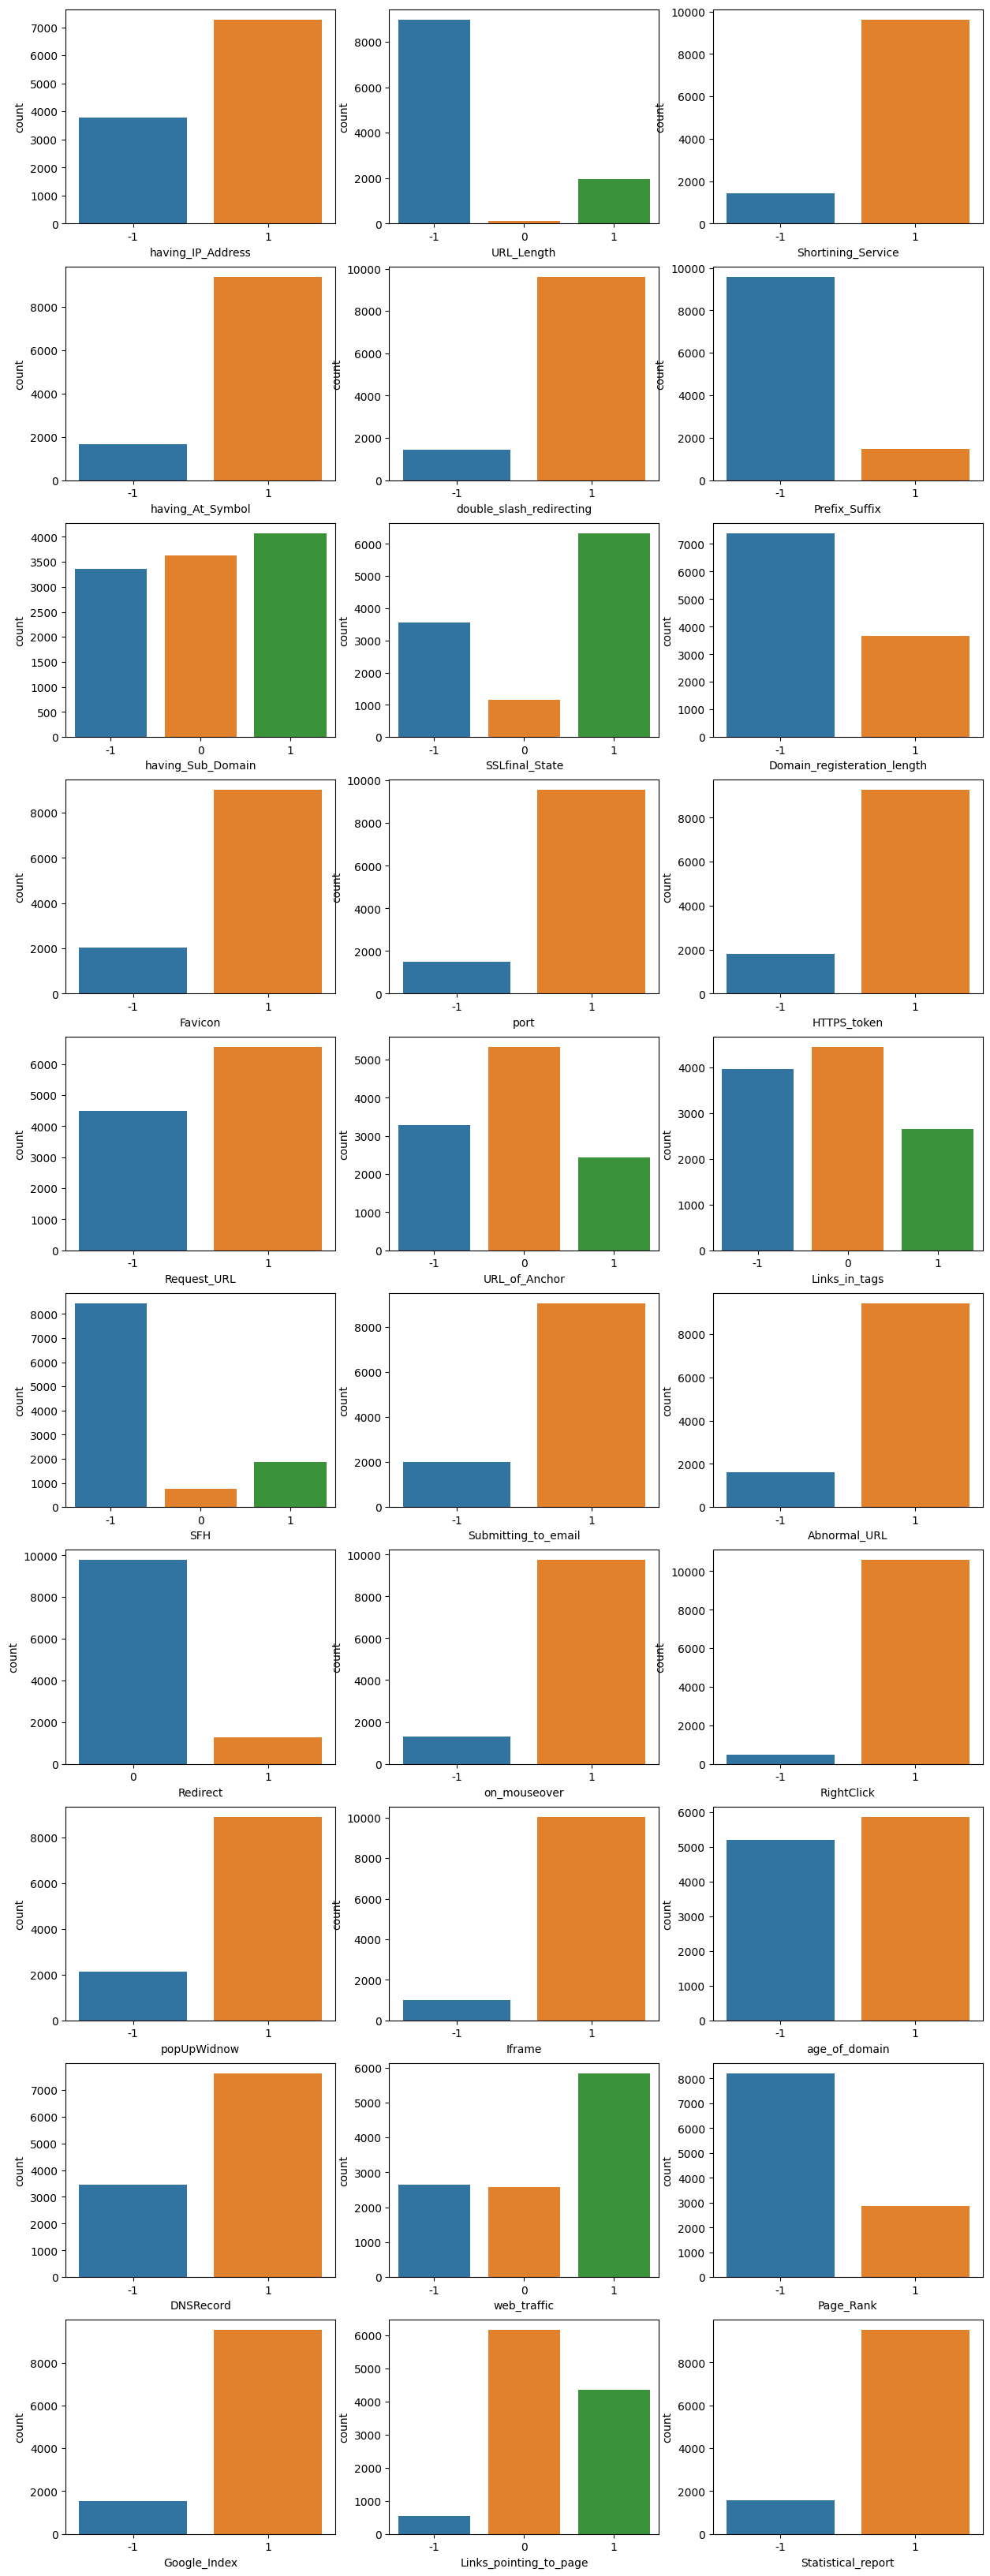

In [8]:
plt.figure(figsize=(15,50),facecolor='white')
plotnumber = 1
for column in df.drop(["Result"], axis = 1):
    ax = plt.subplot(12, 3, plotnumber)
    sns.countplot(x=df[column], ax=ax)
    plt.xlabel(column, fontsize=10)
    plotnumber += 1
plt.show()

In [9]:
df['Result'].value_counts()

Result
 1    6157
-1    4898
Name: count, dtype: int64

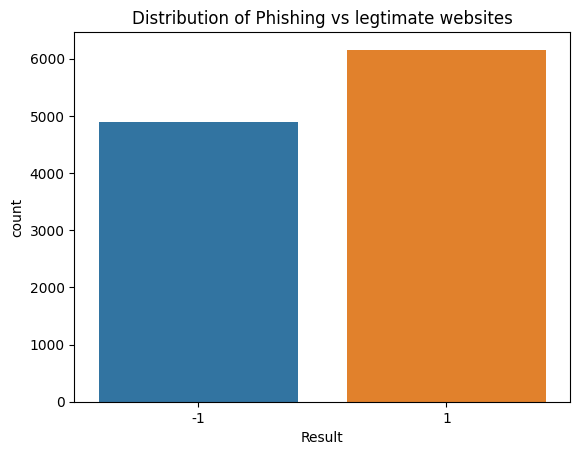

In [10]:
sns.countplot(data= df, x = 'Result')
plt.title('Distribution of Phishing vs legtimate websites')
plt.show()

In [11]:
df.duplicated().sum()

5206

In [12]:
df.duplicated(subset=df.columns[:-1]).sum()

5270

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(5849, 31)

In [15]:
df['Result'].value_counts()

Result
-1    3019
 1    2830
Name: count, dtype: int64

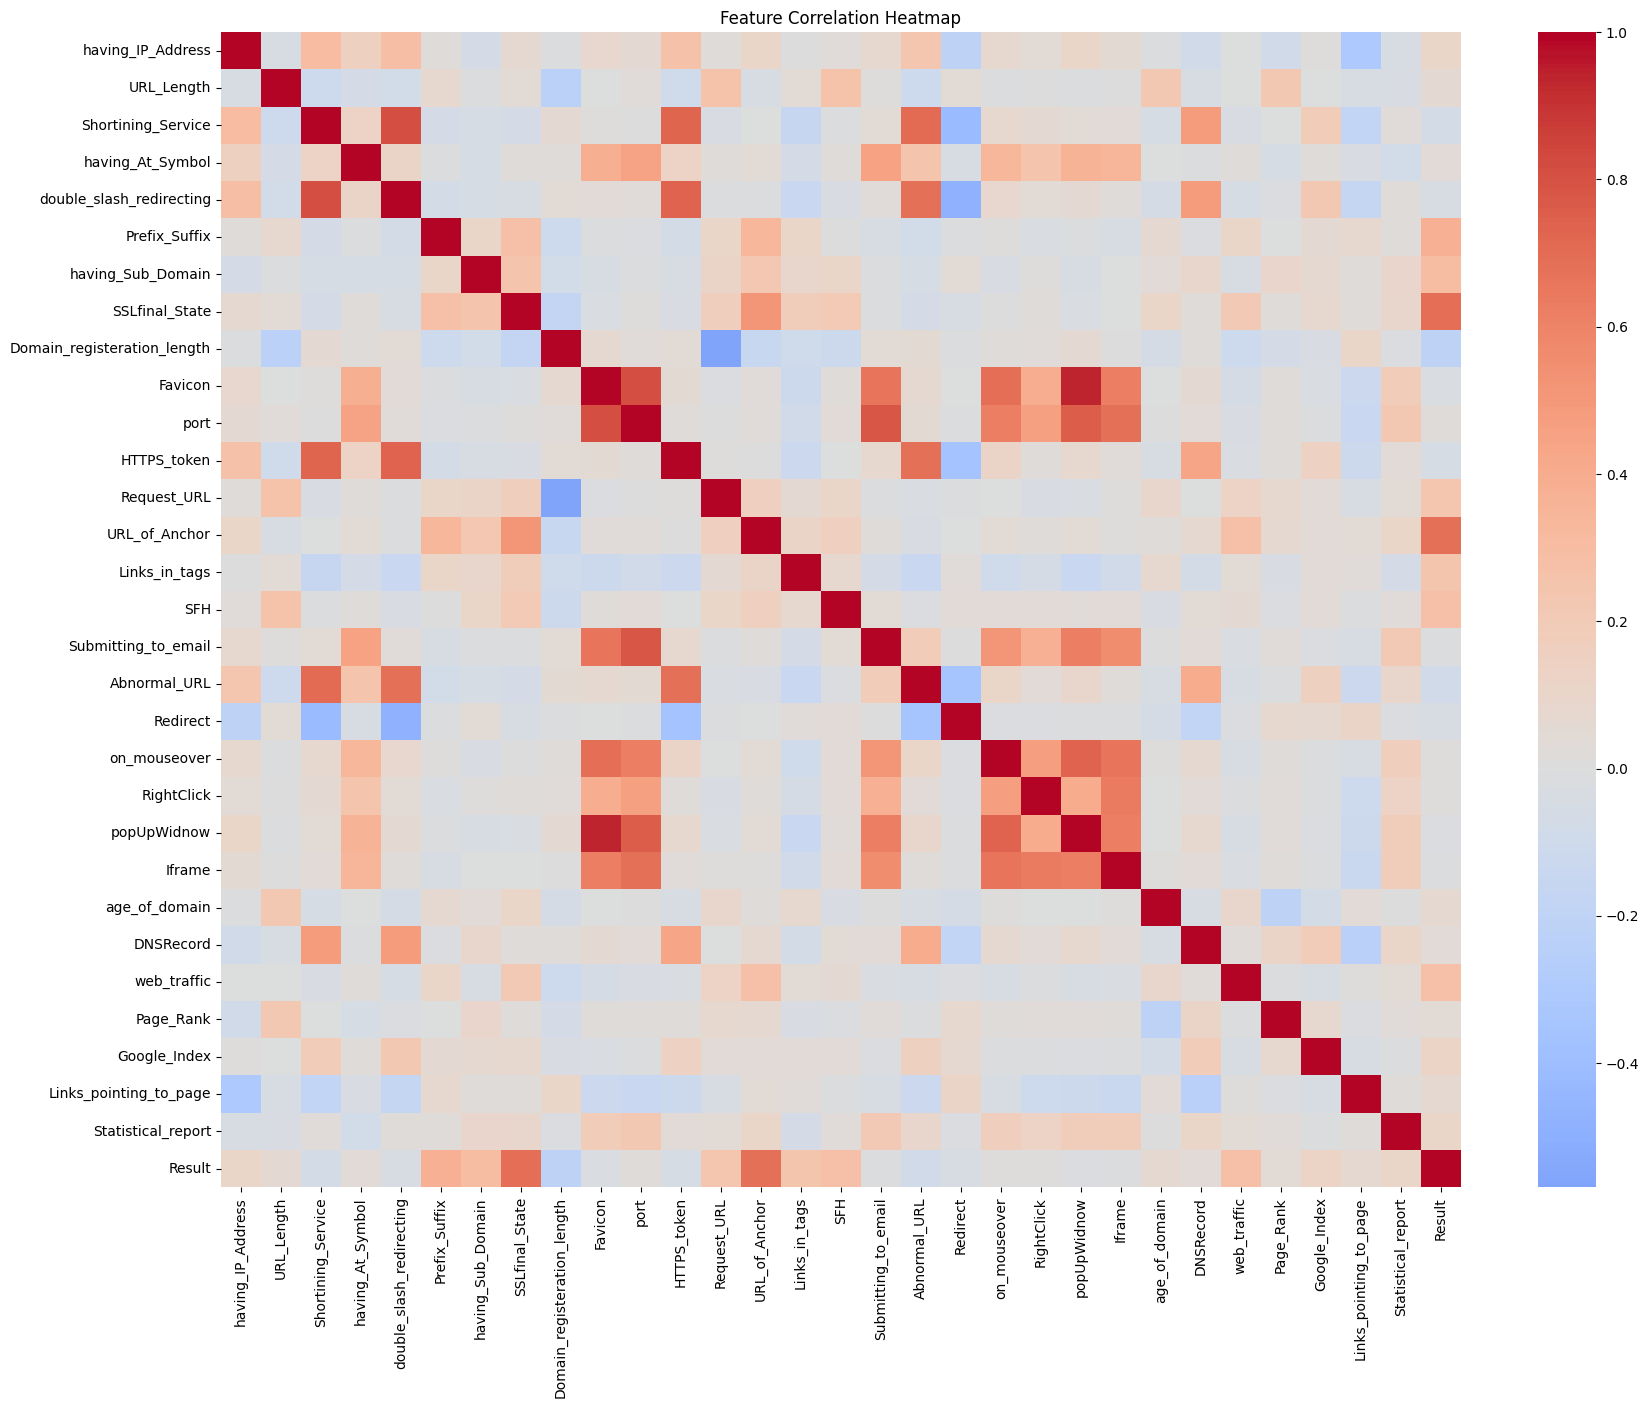

In [16]:
plt.figure(figsize=(20,15))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center= 0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [17]:
df.corr()["Result"].sort_values(ascending=False)

Result                         1.000000
SSLfinal_State                 0.693228
URL_of_Anchor                  0.679125
Prefix_Suffix                  0.381134
having_Sub_Domain              0.296214
web_traffic                    0.281709
SFH                            0.281131
Links_in_tags                  0.243864
Request_URL                    0.237778
Google_Index                   0.118217
Statistical_report             0.108486
having_IP_Address              0.104952
Links_pointing_to_page         0.068463
age_of_domain                  0.062800
URL_Length                     0.058228
Page_Rank                      0.048140
having_At_Symbol               0.034757
DNSRecord                      0.033204
port                           0.014201
on_mouseover                   0.012790
RightClick                     0.009286
Submitting_to_email           -0.008014
Iframe                        -0.011756
popUpWidnow                   -0.022455
Favicon                       -0.025457


SSLfinal_State and URL_of_Anchor — are two most powerful predictors with correlation (0.69, 0.68). 
Ye matches with domain knowledge: SSL certificate ka status aur website ke anchor links kaha point karte hain, ye phishing detect karne ke bahut reliable signals hain.
Kuch features almost zero correlation dikha rahe hain (port, RightClick, on_mouseover, etc. — 0.01 se bhi kam). 
Ye linearly target ke saath connected nahi lag rahe.

Correlation sirf linear relationship measure karta hai. Ho sakta hai ye features non-linear tarike se important hon 
(jaise combination mein, ya tree-based models ke splits mein useful hon). 
Isliye humein abhi inko drop nahi karna chahiye — model training ke baad feature importance (jo tree-based models khud batate hain) se hi final decide karenge kaunse features actually useless hain.